## **Import libraries**

In [1]:
import os
import random

import itertools
import random
from collections import defaultdict
from pathlib import Path

SEED = 8
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
rng = random.Random(SEED)

import numpy as np
from collections import defaultdict

import torch
from transformers import set_seed as transformers_set_seed

def seed_everything(seed: int = SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    transformers_set_seed(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False
    torch.use_deterministic_algorithms(True)

seed_everything(SEED)

from SARVI.config import (
    paths
)
from SARVI.models.schemas import (
    PipelineContext,
    LLMConfig
)

from SARVI.data_io.reader import (
    read_excel_single
)
from SARVI.services.common.tree_funcs import (
    load_tree_hierarchical_module
)

from SARVI.data_io.reader import (
    read_parquet_file, tqdm
)
from SARVI.data_io.writing import (
    write_parquet
)

## **Initialize variables**

In [ ]:
llm_config = LLMConfig(
    service="vllm",
    model="openai/gpt-oss-20b",
    device="cuda" if torch.cuda.is_available() else "cpu"
)

ctx = PipelineContext(
    ussage="deterministic",
    folder_and_archive_name="CT-EBM-SP-v3/train",
    llm_config=llm_config,
    paths=paths,
    cie_10_version="2026",
    json_parse=False,
    device = "cuda" if torch.cuda.is_available() else "cpu"
)

## **Create definition functions**

In [3]:
def create_all_labels_desc(ctx: "PipelineContext", label2id: dict, max_synonym_sentences: int = 10):
    """
    Crea un diccionario de embeddings de descripciones para todas las etiquetas, combinando información de distintos conjuntos de datos.

    Parameters
    ----------
        `ctx`: PipelineContext
            - Contexto del modelo completo
        `label2id`: dict
            - Diccionario con la traduccion de códigos a ids

    Returns
    -------
        `all_labels_desc`: dict
            - Diccionario donde cada clave es el ID numérico de una etiqueta y cada valor es un tensor con los embeddings de las descripciones asociadas a esa etiqueta
    """
    df = read_parquet_file(ctx, "full_icd10_2026.parquet")
    df["target_id"] = df["Code Perceiver"].map(label2id)

    all_labels_desc_ORIGINAL = defaultdict(list)
    for code in tqdm(df.groupby(["target_id"], group_keys=True)[["Description"]], desc="Gathering diags definitions: Original dictionary", unit="diag"):
        all_labels_desc_ORIGINAL[code[0][0]] = code[1]["Description"].to_list()

    ####################################

    df = read_parquet_file(ctx, "codiesp_train.parquet")
    df = df[df["All Code Full"].str.len() > 0]
    df["target_id"] = df["All Code Perceiver"].apply(lambda x: [label2id[c] for c in x])

    all_labels_desc_CODIESP = defaultdict(list)
    for _,row in tqdm(df.iterrows(), total=len(df), desc="Gathering diags definitions: CodiEsp", unit="diag"):
        for code,desc in zip(row["target_id"], row["All Description"]):
            all_labels_desc_CODIESP[code].append(desc)

    ####################################

    df = read_parquet_file(ctx, "cares_train.parquet")
    df = df[df["All Code Full"].str.len() > 0]
    df["target_id"] = df["All Code Perceiver"].apply(lambda x: [label2id[c] for c in x])

    all_labels_desc_CARES = defaultdict(list)
    for _,row in tqdm(df.iterrows(), total=len(df), desc="Gathering diags definitions: CARES", unit="diag"):
        for code,desc in zip(row["target_id"], row["All Description"]):
            all_labels_desc_CARES[code].append(desc)

    ####################################

    df = read_parquet_file(ctx, "cares_test.parquet")
    df = df[df["All Code Full"].str.len() > 0]
    df["target_id"] = df["All Code Perceiver"].apply(lambda x: [label2id[c] for c in x])

    for _,row in tqdm(df.iterrows(), total=len(df), desc="Gathering diags definitions: CARES", unit="diag"):
        for code,desc in zip(row["target_id"], row["All Description"]):
            all_labels_desc_CARES[code].append(desc)

    ####################################

    df = read_parquet_file(ctx, "not_codiesp_cares_general.parquet")
    all_labels_desc_REST = dict(zip(df["All Code Full"].map(label2id), df["All Description"]))
    
    ####################################

    all_labels_desc = {}

    for code in tqdm(all_labels_desc_ORIGINAL.keys(), total=len(all_labels_desc_ORIGINAL), desc="Gathering diags definitions: Embedding definitions", unit="diag"):
        codes_desc_REAL = list(set(all_labels_desc_CODIESP[code] + all_labels_desc_CARES[code]))
        if codes_desc_REAL == []:
            codes_desc_REAL = list(set(all_labels_desc_REST[code]))
        if len(codes_desc_REAL) == max_synonym_sentences:
            all_labels_desc[code] = codes_desc_REAL
        elif len(codes_desc_REAL) > max_synonym_sentences:
            all_labels_desc[code] = list(set(rng.sample(codes_desc_REAL, min(max_synonym_sentences-10, len(codes_desc_REAL))) + rng.sample(all_labels_desc_ORIGINAL[code], min(10, len(all_labels_desc_ORIGINAL[code])))))
        else:
            all_labels_desc[code] = list(set(codes_desc_REAL + rng.sample(all_labels_desc_ORIGINAL[code], min(max_synonym_sentences-len(codes_desc_REAL), len(all_labels_desc_ORIGINAL[code])))))

    return all_labels_desc

In [4]:
def _load_equivalences(paths):
    equivalents = defaultdict(set)
    for path in paths:
        with open(path, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line or "|" not in line:
                    continue
                left, right = [part.strip().lower() for part in line.split("|", 1)]
                if left and right and left != right:
                    equivalents[left].add(right)
                    equivalents[right].add(left)
    return equivalents

def _as_description_list(value):
    if value is None:
        return []
    if isinstance(value, str):
        return [value]
    return list(value)

equivalents = _load_equivalences([Path("/mnt/storage/jrodriguezme/SARVI/docs/MedLexSp_v2/LR/LR_abr.dsv"), Path("/mnt/storage/jrodriguezme/SARVI/docs/MedLexSp_v2/LR/LR_adj_n.dsv")])

def create_medlex_synonyms_per_label(labels_desc: dict, equivalents: defaultdict, max_synonym_sentences: int = 10):
    """
    Returns one item per label with the generated complete synonym sentences.
    Words are split normally using spaces.
    """

    synonym_sentences_by_label = {}

    for label, descriptions in labels_desc.items():
        label_synonym_sentences = []

        for description in _as_description_list(descriptions):
            if len(label_synonym_sentences) >= max_synonym_sentences:
                break
            description = str(description)
            words = description.split(" ")

            replacement_options = []
            has_replacement = False

            for word in words:
                replacements = sorted(equivalents.get(word.lower(), ()))
                if replacements:
                    has_replacement = True
                    replacement_options.append(replacements)
                else:
                    replacement_options.append([word])

            if has_replacement and max_synonym_sentences > 0:
                remaining_synonyms = max_synonym_sentences - len(label_synonym_sentences)
                combinations = itertools.islice(itertools.product(*replacement_options), remaining_synonyms)

                for combination in combinations:
                    label_synonym_sentences.append(" ".join(combination))

        synonym_sentences_by_label[label] = label_synonym_sentences

    return synonym_sentences_by_label

## **Load variables**

In [5]:
df_reference = read_excel_single(ctx, "Diagnosticos_ES2026.xlsx", sheet_name="ES2026 Completa + Marcadores", header=0)
df_reference = df_reference[["Código", "Descripción"]].reset_index(drop=True)
df_reference["Código"] = (df_reference["Código"].astype(str).str.strip().str.replace("\xa0", "", regex=False))
df_reference = df_reference[df_reference["Código"].str.match(r"^[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?(?:-[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?)?$")]

node_list = load_tree_hierarchical_module(df_reference)
root = node_list["root"]

root.set_indexes()
label2id_hs = {key.name: value for key, value in root.node_to_id.items()}
id2label_hs = {value: key for key, value in label2id_hs.items()}
label2id_no_hs = {id2label_hs[value.item()]: i for i, value in enumerate(root.leaf_indexes)}
id2label_no_hs = {value: key for key, value in label2id_no_hs.items()}

Hierarchical tree construction: Cleaning data:   0%|          | 0/102426 [00:00<?, ?code/s]

## **Construct definitive dict**

In [6]:
all_labels_desc = create_all_labels_desc(ctx, label2id_no_hs, 100)
all_labels_synonyms = create_medlex_synonyms_per_label(all_labels_desc, equivalents, 100)

Gathering diags definitions: Original dictionary:   0%|          | 0/1917 [00:00<?, ?diag/s]

Gathering diags definitions: CodiEsp:   0%|          | 0/830 [00:00<?, ?diag/s]

Gathering diags definitions: CARES:   0%|          | 0/2252 [00:00<?, ?diag/s]

Gathering diags definitions: CARES:   0%|          | 0/966 [00:00<?, ?diag/s]

Gathering diags definitions: Embedding definitions:   0%|          | 0/1917 [00:00<?, ?diag/s]

In [7]:
all_labels = {key: all_labels_desc[key] + all_labels_synonyms[key] for key in all_labels_desc.keys()}


## **Simple statistics**

In [5]:
def sort_dict_by_keys(d: dict[int, int]) -> dict[int, int]:
    """
    Sort a dictionary by its integer keys.

    Example:
        {3: 10, 1: 5, 2: 7} -> {1: 5, 2: 7, 3: 10}
    """
    return dict(sorted(d.items()))

import matplotlib.pyplot as plt


def plot_dict_counts(d: dict[int, int], title: str = "Distribution of number of definitions") -> None:
    """
    Plot dictionary keys on the x-axis and values/counts on the y-axis.
    """
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman"],
        "font.size": 9,
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "axes.linewidth": 0.8,
        "lines.linewidth": 1.2,
        "lines.markersize": 4.5,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

    page_width = 3.5
    figure_height = page_width * 3 / 4

    sorted_d = sort_dict_by_keys(d)

    x = list(sorted_d.keys())
    y = list(sorted_d.values())

    plt.figure(figsize=(page_width, figure_height))
    plt.bar(x, y)
    plt.xlabel("Nº definitions")
    plt.ylabel("Nº keys w/ Nº definitions")
    # plt.title(title)
    plt.tight_layout()
    plt.savefig("plot.pdf", format="pdf")
    plt.show()

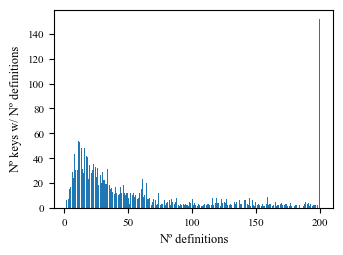

In [6]:
from SARVI.models.schemas import (
    PipelineContext,
    LLMConfig
)
from SARVI.config import paths

llm_config = LLMConfig(
    service="vllm",
    model="openai/gpt-oss-20b",
    device="cuda"
)

ctx = PipelineContext(
    ussage="deterministic",
    folder_and_archive_name="CT-EBM-SP-v3/train",
    llm_config=llm_config,
    paths=paths,
    cie_10_version="2026",
    json_parse=False,
    device = "cuda",
    base_encoder_name="f"
)

from pathlib import Path
from matplotlib import font_manager
import matplotlib.pyplot as plt

font_dir = Path.home() / ".local/share/fonts/TimesNewRoman"

for font_file in font_dir.glob("*.ttf"):
    font_manager.fontManager.addfont(str(font_file))

plt.rcParams.update({
    "font.family": "Times New Roman",
})

import logging
logging.getLogger("fontTools").setLevel(logging.WARNING)

from SARVI.data_io.reader import read_parquet_file
all_labels = read_parquet_file(ctx, "all_label_description.parquet")

from collections import defaultdict
counts = defaultdict(int)
for i,row in all_labels.iterrows():
    counts[len(row["All Description"])] += 1
plot_dict_counts(dict(sorted(counts.items())))

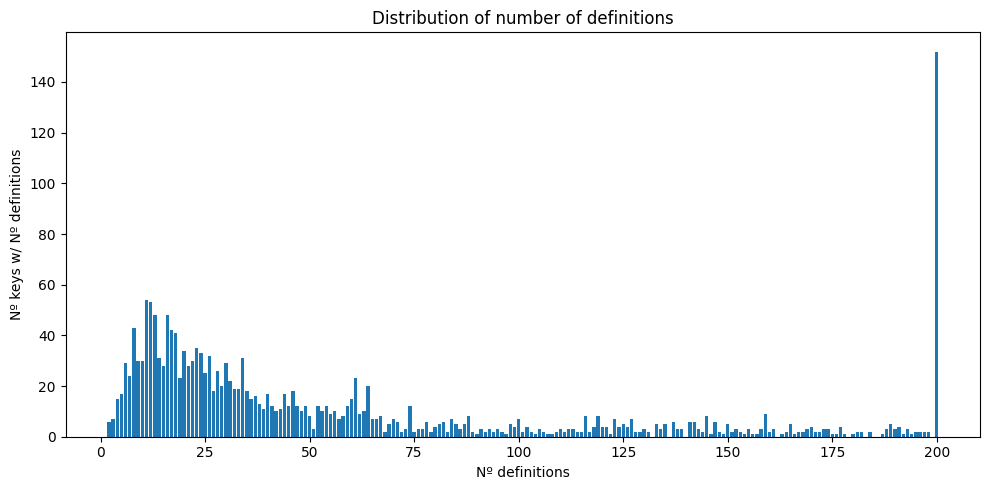

In [ ]:
counts = defaultdict(int)

for key,value in all_labels.items():
    counts[len(value)] += 1

plot_dict_counts(dict(sorted(counts.items())))

## **Save new dict**

In [15]:
import pandas as pd

df = pd.DataFrame([(id2label_no_hs[k], v) for k, v in all_labels.items()], columns=["All Code Full", "All Description"])
display(df)

,All Code Full,All Description
0,A00,"[Cólera debido a Vibrio cholerae 01, biotipo c..."
1,A01,"[Neumonía tifoidea, fiebre tifoidea, Fiebre pa..."
2,A02,"[Meningitis por Salmonella, Enteritis debida a..."
3,A03,"[Otras shigelosis, Shigelosis debida a Shigell..."
4,A04,"[Campylobacter jejuni, Enterocolitis debida a ..."
...,...,...
1912,Z19,"[cáncer hormono resistente, cáncer con respues..."
1913,Z66,"[Reanimación cardiopulmonar no aplicada, Ausen..."
1914,Z67,"[Duffy a positivo, grupo sanguíneo A positivo,..."
1915,Z68,"[Índice de masa corporal [IMC] 45.0-49.9, adul..."


In [16]:
write_parquet(ctx, "all_label_description", df)